# Estimating multinomial logistic intercepts with gradient boosting

This short notebook is meant to showcase quality issues with vector-leaf gradient boosting based on diagonal-only upper bounds of the Hessian, compared to using the actual Hessian.

In this example, it tries to estimate the optimal intercepts of a multinomial logistic problem on the first 5,000 observations of the CovType dataset by successive Newton iterations, without a line search.

Since the problem is unregularized, it sets the last class as the reference class, esimating 6 parameters in total.

# A look at the dataset

In [1]:
import numpy as np
from sklearn.datasets import fetch_covtype
_, y = fetch_covtype(return_X_y=True)
y = y[:5_000]

y = (y - 1).astype(int)
k = y.max() + 1
n = y.shape[0]

Y_wide = np.zeros((y.shape[0], y.max() + 1))
Y_wide[np.arange(n), y] = 1.
Y_wide.mean(axis=0)

array([0.1114, 0.1896, 0.1286, 0.2498, 0.189 , 0.0958, 0.0358])

# Multinomial logistic function, gradient and Hessian

These assume that the `x` supplied is a vector of length $k-1$, which is the same for all observations.

In [2]:
from scipy.special import softmax

# Function, gradient and Hessian for multinomial logistic
# with a reference class. Only 'k-1' raw scores are given.
def mnl_function(x, Y_wide):
    # last class is reference class, constrained to zero
    x = np.r_[x, np.zeros(1)]
    p = softmax(x).reshape((1, -1))
    return -np.sum(
        Y_wide*np.log(p) + (1-Y_wide)*np.log(1-p)
    )
def mnl_grad(x, Y_wide):
    k1 = x.shape[0]
    x = np.r_[x, np.zeros(1)]
    p = softmax(x).reshape((1, -1))
    return (Y_wide - p)[:, :k1]
def mnl_hess(x, Y_wide):
    k1 = x.shape[0]
    x = np.r_[x, np.zeros(1)]
    p = softmax(x)
    n = Y_wide.shape[0] # same hessian for all observations
    k = x.shape[0]
    return np.broadcast_to(
        np.diag(p) - np.outer(p,p),
        (n, k, k),
    )[:, :k1, :k1]

# Reference solutions

In [3]:
# Verify correctness of closed form
from scipy.optimize import minimize
sol_scipy = minimize(
    mnl_function,
    np.zeros(k-1), args=(Y_wide,),
    method="Nelder-Mead",
    options={"maxiter": 10_000}
)["x"]

sol_closed_form = np.log(Y_wide.mean(axis=0))
sol_closed_form -= sol_closed_form[-1]
sol_closed_form = sol_closed_form[:-1]

sol_scipy, sol_closed_form

(array([1.13517494, 1.6669703 , 1.27876539, 1.94274675, 1.66383402,
        0.98433683]),
 array([1.13517943, 1.6669687 , 1.27875892, 1.9427127 , 1.66379912,
        0.98431479]))

In [4]:
mnl_function(sol_closed_form, Y_wide)

np.float64(13678.952061597256)

# Solving the problem by gradient boosting

In [5]:
def get_leafs_upper_bound(x):
    grad = mnl_grad(x, Y_wide)
    Hess = mnl_hess(x, Y_wide)
    Hess_ub = np.vstack([
        2 * np.diag(Hess[row])
        for row in range(Y_wide.shape[0])
    ])
    return grad.sum(axis=0) / Hess_ub.sum(axis=0)
def get_leafs_true_hess(x):
    grad = mnl_grad(x, Y_wide)
    Hess = mnl_hess(x, Y_wide)
    return np.linalg.solve(
        Hess.sum(axis=0),
        grad.sum(axis=0),
    )

sol_gbt_diagbound = np.zeros(k-1)
sol_gbt_truehess = np.zeros(k-1)

max_n_iter = 500
fn_history_diabound = np.empty(max_n_iter)
fn_history_truehess = np.empty(max_n_iter)

for newton_iter in range(max_n_iter):
    fn_diagbound = mnl_function(sol_gbt_diagbound, Y_wide)
    fn_truehess = mnl_function(sol_gbt_truehess, Y_wide)
    fn_history_diabound[newton_iter] = fn_diagbound
    fn_history_truehess[newton_iter] = fn_truehess

    if (newton_iter < 10) or (newton_iter >= (max_n_iter - 10)):
        print(
            f"iter{newton_iter}: f(x) truehess: {fn_truehess}"
            f" | f(x) diagbound: {fn_diagbound}" 
        )
    sol_gbt_diagbound += get_leafs_upper_bound(sol_gbt_diagbound)
    sol_gbt_truehess += get_leafs_true_hess(sol_gbt_truehess)
sol_gbt_truehess, sol_gbt_diagbound

iter0: f(x) truehess: 14354.071140094313 | f(x) diagbound: 14354.071140094313
iter1: f(x) truehess: 13726.922001264507 | f(x) diagbound: 14019.49455502901
iter2: f(x) truehess: 13680.200667692543 | f(x) diagbound: 13948.495174326483
iter3: f(x) truehess: 13678.955221957614 | f(x) diagbound: 13913.90328299141
iter4: f(x) truehess: 13678.952061620952 | f(x) diagbound: 13888.431488861735
iter5: f(x) truehess: 13678.952061597256 | f(x) diagbound: 13867.194283447512
iter6: f(x) truehess: 13678.952061597258 | f(x) diagbound: 13848.913143522012
iter7: f(x) truehess: 13678.952061597256 | f(x) diagbound: 13832.9900976497
iter8: f(x) truehess: 13678.952061597254 | f(x) diagbound: 13819.021064146156
iter9: f(x) truehess: 13678.952061597254 | f(x) diagbound: 13806.6962013315
iter490: f(x) truehess: 13678.952061597254 | f(x) diagbound: 13678.952061619455
iter491: f(x) truehess: 13678.952061597254 | f(x) diagbound: 13678.952061618498
iter492: f(x) truehess: 13678.952061597256 | f(x) diagbound: 13678

(array([1.13517943, 1.6669687 , 1.27875892, 1.9427127 , 1.66379912,
        0.98431479]),
 array([1.1351668 , 1.66695611, 1.27874629, 1.94270015, 1.66378653,
        0.98430215]))

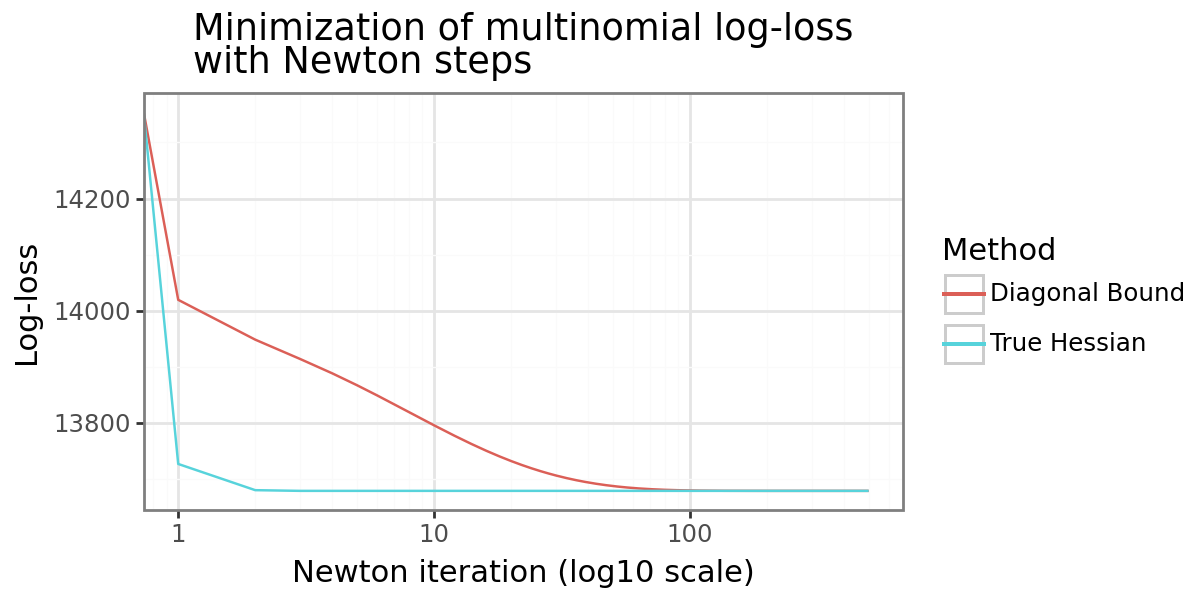

In [6]:
import plotnine as p9
import polars as pl
import warnings

df_fn = pl.DataFrame({
    "True Hessian": fn_history_truehess,
    "Diagonal Bound": fn_history_diabound,
    "Newton Iteration": np.arange(max_n_iter),
})
df_fn = df_fn.unpivot(index="Newton Iteration", variable_name="Method", value_name="Log-loss")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    (
        p9.ggplot(df_fn, p9.aes(x="Newton Iteration", y="Log-loss", color="Method"))
        + p9.theme_bw()
        + p9.geom_line()
        + p9.scale_x_log10()
        + p9.ggtitle(
            "Minimization of multinomial log-loss"
            "\nwith Newton steps"
        )
        + p9.xlab("Newton iteration (log10 scale)")
        + p9.theme(figure_size=(6,3))
    ).show()

In [7]:
crit_converged = mnl_function(sol_closed_form, Y_wide) + 1e-6
truehess_is_converged = fn_history_truehess <= crit_converged
diagbound_is_converged = fn_history_diabound <= crit_converged
niter_converge_truehess = np.arange(max_n_iter)[truehess_is_converged].min()
niter_converge_diagbound = np.arange(max_n_iter)[diagbound_is_converged].min()
niter_converge_truehess, niter_converge_diagbound

(np.int64(4), np.int64(404))